# IRI trend
<!-- markdownlint-disable-line MD013 -->
Check trend of overall activation prob.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ocha_stratus as stratus

from src.constants import *

## Load and process data

In [3]:
blob_name = f"{PROJECT_PREFIX}/raw/iri/ner_trigger_comparison_2025_newmodel_adjustment - raw.csv"

In [4]:
df_iri_raw = stratus.load_csv_from_blob(blob_name, skiprows=3).dropna()
df_iri_raw.columns = ["year"] + [
    calendar.month_abbr[x] for x in [y for y in range(1, 7)] + [8]
]
df_iri_raw["year"] = df_iri_raw["year"].astype(int)

## Calculate activation prob. and plot

See how activation probability changes as we adjust start year of analysis (we have previously used 1998 as a convention, since there were several activations before this).

In [14]:
def calculate_activations(ind_frac: float):
    """Calculate activations based on logic in framework"""
    df_iri = df_iri_raw.copy()
    for x in df_iri:
        if "bool" in x or x == "year":
            continue
        if x == "Aug":
            df_iri[f"{x}_bool"] = df_iri[x] <= df_iri[x].quantile(ind_frac)
        else:
            df_iri[f"{x}_bool"] = df_iri[x] >= df_iri[x].quantile(1 - ind_frac)

    for mo_int in range(1, 6):
        mo1 = calendar.month_abbr[mo_int]
        mo2 = calendar.month_abbr[mo_int + 1]
        df_iri[f"{mo1}{mo2}_consec"] = (
            df_iri[f"{mo1}_bool"] & df_iri[f"{mo2}_bool"]
        )

    cols_w1 = ["JanFeb_consec", "FebMar_consec"]
    df_iri["w1"] = df_iri[cols_w1].any(axis=1)

    cols_w2 = ["MarApr_consec", "AprMay_consec", "MayJun_consec", "Aug_bool"]
    df_iri["w2"] = df_iri[cols_w2].any(axis=1)

    df_iri["any"] = df_iri["w1"] | df_iri["w2"]

    dicts = []
    for year in df_iri["year"].unique():
        dff = df_iri[df_iri["year"] >= year]
        n_years = len(dff)
        n_activations = dff["any"].sum()
        rp = (n_years + 1) / n_activations if n_activations > 0 else np.inf
        prob = 1 / rp
        p = n_activations / n_years
        # Bernoulli standard error
        se = np.sqrt((p * (1 - p) / n_years))
        dicts.append(
            {"min_year": year, "rp": rp, "prob": 1 / rp, "se": se, "p": p}
        )

    df_rp = pd.DataFrame(dicts)
    df_rp["upper_p"] = df_rp["p"] + df_rp["se"]
    df_rp["lower_p"] = df_rp["p"] - df_rp["se"]

    return df_rp, df_iri

In [15]:
def plot_rp(df_rp: pd.DataFrame, ind_frac: float):
    max_year = 2020

    fig, ax = plt.subplots(dpi=200)
    df_rp.plot(x="min_year", y="p", ax=ax, color="dodgerblue", legend=False)
    ax.fill_between(
        df_rp["min_year"],
        df_rp["lower_p"],
        df_rp["upper_p"],
        facecolor="dodgerblue",
        alpha=0.3,
    )
    ax.axhline(0.35, color="crimson")
    ax.annotate(
        "0.35 ",
        (df_rp["min_year"].min(), 0.35),
        va="center",
        ha="right",
        color="crimson",
    )

    ax.set_xlim(left=df_rp["min_year"].min(), right=max_year)
    ax.set_ylim(0, 1)

    ax.set_title("Niger drought activation probability estimation")
    ax.text(
        0.5,
        1,
        f"Shaded area ± 1 std. error\nPer-month activation probability {ind_frac:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
    )
    ax.set_ylabel("Overall activation probability")
    ax.set_xlabel("Start year of analysis")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

From plot below, activation probability is too high no matter how late we set the start date of analysis.

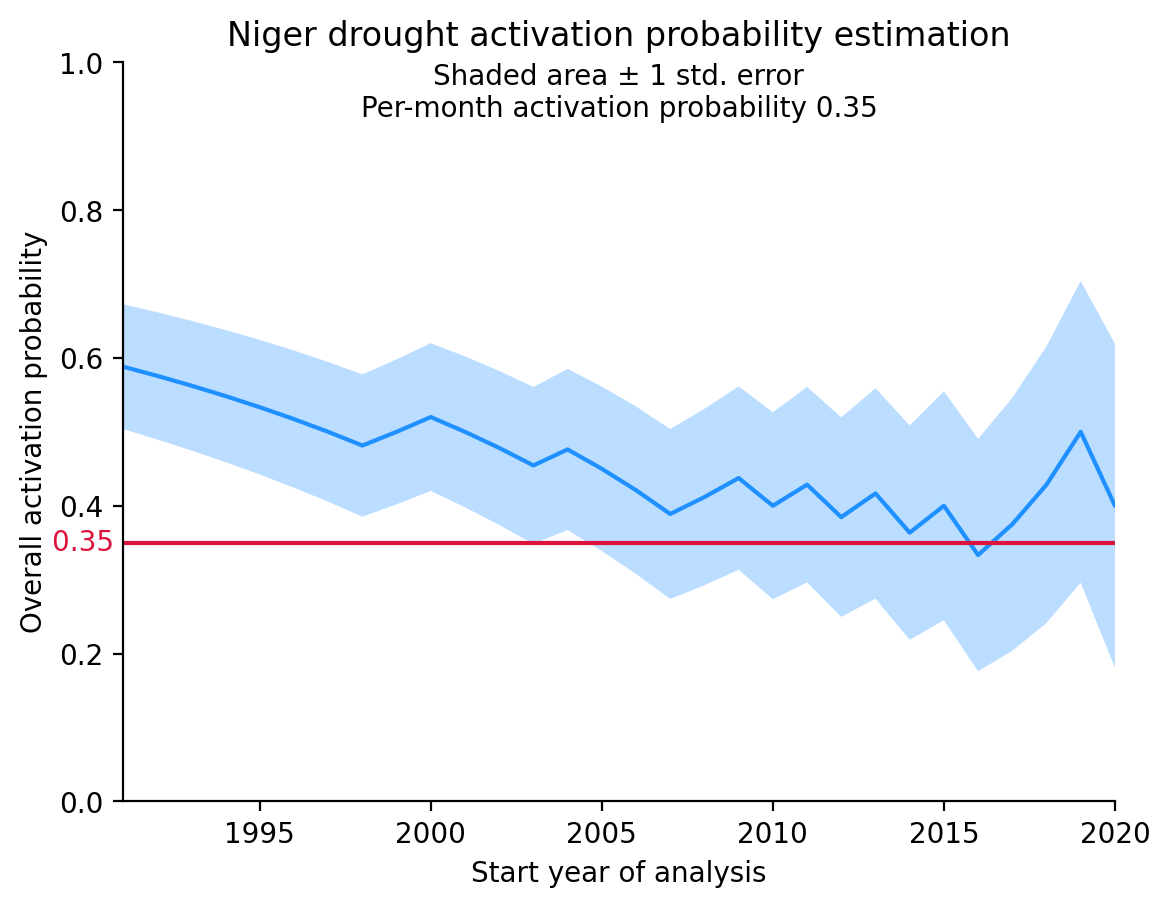

In [16]:
ind_frac = 0.35
df_rp, df_activations = calculate_activations(ind_frac=ind_frac)
plot_rp(df_rp, ind_frac)

In [17]:
df_rp

,min_year,rp,prob,se,p,upper_p,lower_p
0,2024,inf,0.000000,0.000000,0.000000,0.000000,0.000000
1,2023,3.000000,0.333333,0.353553,0.500000,0.853553,0.146447
2,2022,2.000000,0.500000,0.272166,0.666667,0.938832,0.394501
3,2021,2.500000,0.400000,0.250000,0.500000,0.750000,0.250000
4,2020,3.000000,0.333333,0.219089,0.400000,0.619089,0.180911
5,2019,2.333333,0.428571,0.204124,0.500000,0.704124,0.295876
6,2018,2.666667,0.375000,0.187044,0.428571,0.615615,0.241528
7,2017,3.000000,0.333333,0.171163,0.375000,0.546163,0.203837
8,2016,3.333333,0.300000,0.157135,0.333333,0.490468,0.176198
9,2015,2.750000,0.363636,0.154919,0.400000,0.554919,0.245081


However, if we adjust the per-month percentile threshold to `0.3`, we're ok.

Note that this is set to step of `0.05` since this is how the Maproom is designed.

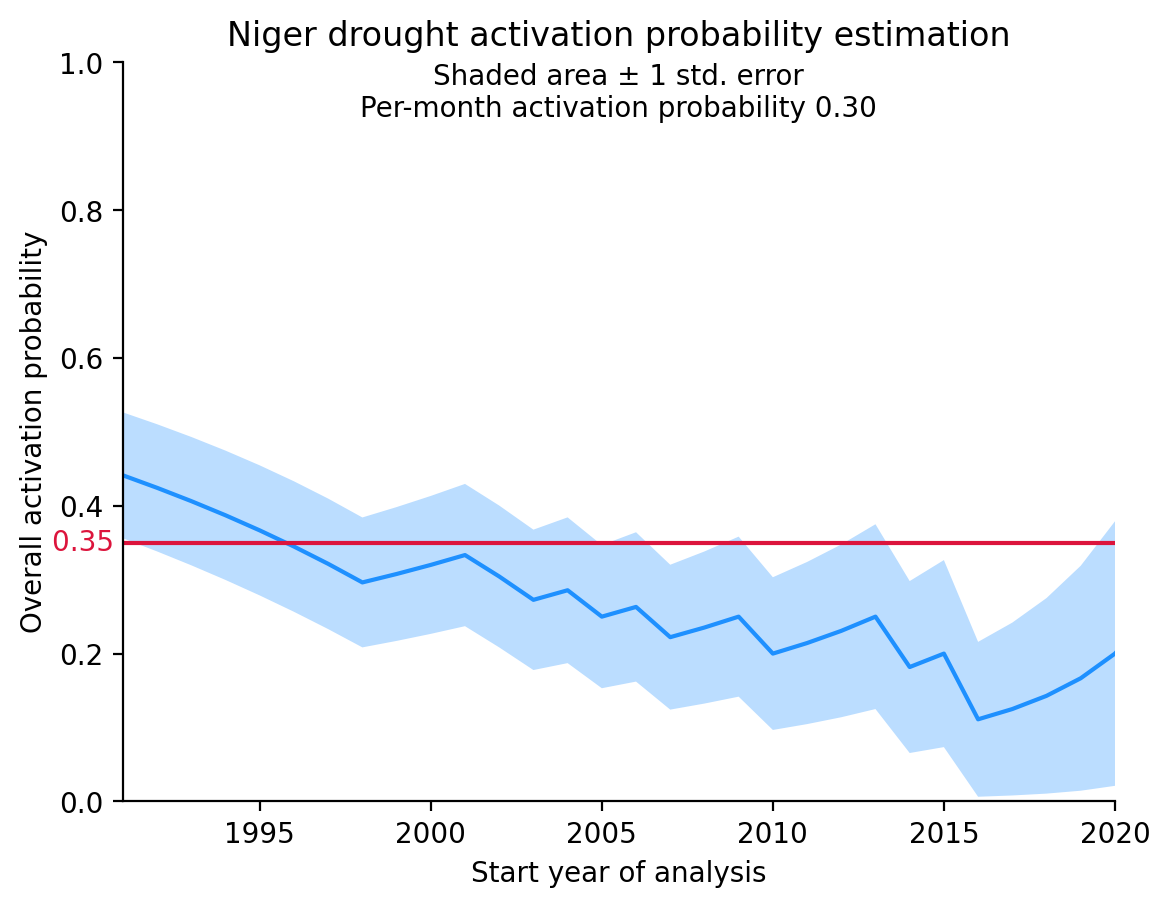

In [18]:
ind_frac = 0.3
df_rp, df_activations = calculate_activations(ind_frac=ind_frac)
plot_rp(df_rp, ind_frac)

## Calculate framework stats

To go in standard reporting table.

In [21]:
ind_frac = 0.3
df_rp, df_activations = calculate_activations(ind_frac=ind_frac)

In [28]:
df_rp

,min_year,rp,prob,se,p,upper_p,lower_p
0,2024,inf,0.000000,0.000000,0.000000,0.000000,0.000000
1,2023,inf,0.000000,0.000000,0.000000,0.000000,0.000000
2,2022,4.000000,0.250000,0.272166,0.333333,0.605499,0.061168
3,2021,5.000000,0.200000,0.216506,0.250000,0.466506,0.033494
4,2020,6.000000,0.166667,0.178885,0.200000,0.378885,0.021115
5,2019,7.000000,0.142857,0.152145,0.166667,0.318812,0.014522
6,2018,8.000000,0.125000,0.132260,0.142857,0.275117,0.010597
7,2017,9.000000,0.111111,0.116927,0.125000,0.241927,0.008073
8,2016,10.000000,0.100000,0.104757,0.111111,0.215868,0.006355
9,2015,5.500000,0.181818,0.126491,0.200000,0.326491,0.073509


In [26]:
WINDOW_1_BUDGET = 5.25
WINDOW_2_BUDGET = 9.6

df_activations["total_spend"] = (
    df_activations["w1"] * WINDOW_1_BUDGET
    + df_activations["w2"] * WINDOW_2_BUDGET
)

In [35]:
df_activations_recent = df_activations[df_activations["year"] >= 1998]
total_years = len(df_activations_recent)

In [49]:
df_activations_recent

,year,Jan,Feb,Mar,Apr,May,Jun,Aug,Jan_bool,Feb_bool,...,Aug_bool,JanFeb_consec,FebMar_consec,MarApr_consec,AprMay_consec,MayJun_consec,w1,w2,any,total_spend
0,2024,14.7,14.1,12.3,15.2,13.1,18.3,1.321,False,False,...,False,False,False,False,False,False,False,False,False,0.00
1,2023,26.2,18.6,27.8,23.6,23.8,32.5,-0.188,False,False,...,False,False,False,False,False,False,False,False,False,0.00
2,2022,18.4,14.1,15.1,14.2,12.8,20.1,-0.496,False,False,...,True,False,False,False,False,False,False,True,True,9.60
3,2021,14.5,12.4,15.8,17.2,15.3,19.5,0.390,False,False,...,False,False,False,False,False,False,False,False,False,0.00
4,2020,18.3,15.7,17.1,16.2,17.5,20.2,0.147,False,False,...,False,False,False,False,False,False,False,False,False,0.00
5,2019,26.9,27.0,29.4,26.2,25.5,28.1,-0.281,False,False,...,False,False,False,False,False,False,False,False,False,0.00
6,2018,17.0,15.8,21.0,21.5,17.2,17.0,0.369,False,False,...,False,False,False,False,False,False,False,False,False,0.00
7,2017,31.1,22.5,30.6,22.0,21.2,26.9,0.599,False,False,...,False,False,False,False,False,False,False,False,False,0.00
8,2016,19.4,18.2,17.3,7.1,14.0,17.6,0.798,False,False,...,False,False,False,False,False,False,False,False,False,0.00
9,2015,33.5,27.5,30.0,14.2,33.9,28.8,-0.474,False,False,...,True,False,False,False,False,False,False,True,True,9.60


In [76]:
w1_rp = (total_years + 1) / df_activations_recent["w1"].sum()
w2_rp = (total_years + 1) / df_activations_recent["w2"].sum()
any_rp = (total_years + 1) / df_activations_recent["any"].sum()

total_spend = df_activations_recent["total_spend"].sum()
avg_spend = total_spend / total_years
avg_spend_activation = total_spend / df_activations_recent["any"].sum()
total_budget = WINDOW_1_BUDGET + WINDOW_2_BUDGET
rp_eff = total_budget / avg_spend

print(f"window 1 RP: {w1_rp:.1f}")
print(f"window 1 prob: {1/w1_rp:.0%}")

print(f"window 2 RP: {w2_rp:.1f}")
print(f"window 2 prob: {1/w2_rp:.0%}")

print(f"any RP: {any_rp:.1f}")
print(f"any prob: {1/any_rp:.0%}")

print(f"average spend: {avg_spend:.1f}")
print(f"rp eff: {rp_eff:.1f}")
print(f"prob eff: {1/rp_eff:.0%}")
print(f"average spend per act.: {avg_spend_activation:.1f}")

window 1 RP: 9.3
window 1 prob: 11%
window 2 RP: 3.5
window 2 prob: 29%
any RP: 3.5
any prob: 29%
average spend: 3.4
rp eff: 4.3
prob eff: 23%
average spend per act.: 11.6


In [72]:
df_activations_recent[df_activations_recent["w1"]].sort_values("year")[
    "year"
].to_list()

[2001, 2002, 2004]

In [73]:
df_activations_recent[df_activations_recent["w2"]].sort_values("year")[
    "year"
].to_list()

[2001, 2002, 2004, 2006, 2009, 2013, 2015, 2022]